# Домашнее задание: Деревья решений и Random Forest

## Общие инструкции

1. Выполните все задания в этом ноутбуке
2. Для каждого задания предоставьте код и краткие объяснения
3. Задания можно выполнять в любом порядке
4. Используйте комментарии в коде для объяснения ваших решений

**Максимальный балл: 20 + 5 (бонус) = 25 баллов**

---


In [ ]:
# Импорты, которые могут понадобиться
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                            mean_absolute_error, mean_squared_error, r2_score)
import seaborn as sns

# Настройка для красивого отображения
plt.rcParams['figure.figsize'] = (16, 8)
sns.set_style("whitegrid")
np.random.seed(42)  # Для воспроизводимости


## Задание 1: Понимание коэффициента Джини (2 балла)

Реализуйте функцию для вычисления коэффициента Джини и решите следующие задачи:

1. Вычислите коэффициент Джини для следующих распределений:
   - [0, 0, 0, 0, 0] (все образцы одного класса)
   - [0, 0, 0, 1, 1] (3 класса 0, 2 класса 1)
   - [0, 1, 0, 1, 0, 1] (равномерное распределение)

2. Визуализируйте коэффициент Джини как функцию доли положительного класса $p$ для бинарной классификации.

3. Объясните, почему коэффициент Джини достигает максимума при $p = 0.5$.


1) gini: 0.0
2) gini: 0.48
3) gini: 0.5


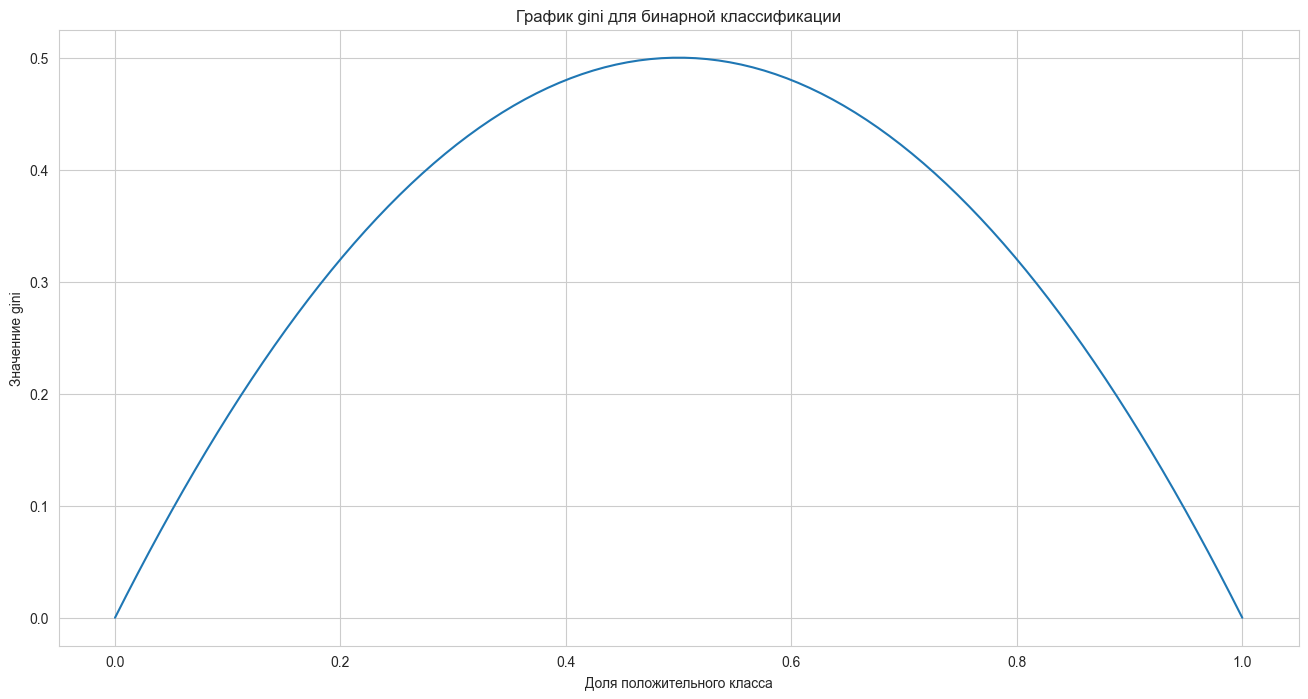

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def gini_impurity(y):
    if len(y) == 0:
        return 0
    _, cnt = np.unique(y, return_counts=True)
    p = cnt / len(y)
    return 1 - np.sum(p**2)

r1 = np.array([0, 0, 0, 0, 0])
r2 = np.array([0, 0, 0, 1, 1])
r3 = np.array([0, 1, 0, 1, 0, 1])
for ind, r in enumerate([r1, r2, r3]):
    print(ind + 1, ") gini: ", gini_impurity(r), sep='')

x = np.linspace(0, 1, 100)
y = -2 * x**2 + 2 * x
plt.plot(x, y)
plt.title("График gini для бинарной классификации")
plt.xlabel("Доля положительного класса")
plt.ylabel("Значенние gini")
plt.show()

# Коэфицент джини это перевёрнутая парабола, с вершиной при p = 0.5 поэтому значение в этой точке максимально


## Задание 2: Вычисление прироста информации (3 балла)

Реализуйте функцию для вычисления прироста информации (Information Gain) и примените её к следующему датасету:

| Погода | Температура (°C) | Играть |
|--------|------------------|--------|
| Солнечно | 30 | Нет |
| Солнечно | 32 | Нет |
| Облачно | 28 | Да |
| Дождь | 22 | Да |
| Дождь | 15 | Да |
| Дождь | 12 | Нет |
| Облачно | 18 | Да |
| Солнечно | 25 | Нет |

**Задачи:**
1. Вычислите энтропию корневого узла (все данные)
2. Вычислите прирост информации для признака "Погода" (категориальный признак)
3. Вычислите прирост информации для признака "Температура" (числовой признак)
   - Для числового признака нужно найти оптимальный порог разбиения
4. Определите, какой признак следует выбрать для первого разбиения
5. Постройте дерево решений вручную (на бумаге или в коде) для этого датасета


In [ ]:
def entropy(y):
    if len(y) == 0:
        return 0
    _, cnt = np.unique(y, return_counts=True)
    p = cnt / len(y)
    p = p[p > 0]
    return -np.sum(p * np.log2(p))

def information_gain(X, y, feature_idx):
    arr = np.unique(X[:, feature_idx])
    h = entropy(y)
    w_entropy = 0
    splits = {}
    for group in arr:
        mask = X[:, feature_idx] == group
        y_child = y[mask]
        if len(y_child) > 0:
            e = entropy(y_child)
            w = len(y_child) / len(y)
            w_entropy += w * e
            splits[group] = {
                'y': y_child,
                'X': X[mask],
                'entropy': e,
                'weight': w,
                'count': len(y_child)
            }
    IG = h - w_entropy
    return IG, splits, h

def information_gain_numeric(X, y, feature_idx):
    arr = np.unique(X[:, feature_idx])
    h = entropy(y)
    IG = 0
    split = None
    for i in range(len(arr) - 1):
        m = (arr[i] + arr[i + 1]) / 2
        mask = X[:, feature_idx] < m
        y_child1 = y[mask]
        y_child2 = y[~mask]
        if len(y_child1) > 0 and len(y_child2) > 0:
            e1 = entropy(y_child1)
            e2 = entropy(y_child2)
            w1 = len(y_child1) / len(y)
            w2 = len(y_child2) / len(y)
            w_entropy = w1 * e1 + e2 * w2
            if h - w_entropy > IG:
                IG = h - w_entropy
                split = {
                    'average': m,
                    'y_left': y_child1,
                    'y_right': y_child2,
                    'X_left': X[mask],
                    'X_right': X[~mask],
                    'entropy_left': e1,
                    'entropy_right': e2,
                    'weight_left': w1,
                    'weight_right': w2,
                    'count_left': len(y_child1),
                    'count_right': len(y_child2)
                }
    return IG, split, h

data = np.array([
    [0, 30, 0],
    [0, 32, 0],
    [1, 28, 1],
    [2, 22, 1],
    [2, 15, 1],
    [2, 12, 0],
    [1, 18, 1],
    [0, 25, 0],
])

X = data[:, :-1]
y = data[:, -1]
print("прирост информации для признака Погода:", information_gain(X, y, 0)[0])
print("прирост информации для признака Температура:", information_gain_numeric(X, y, 1)[0])


прирост информации для признака Погода: 0.6556390622295665
прирост информации для признака Температура: 0.31127812445913283


Лучший признак погода тк 0.65 > 0.31

In [ ]:
split1 = information_gain(X, y, 0)[1]
for key in split1:
    print(key, split1[key])

split2 = information_gain_numeric(split1[2]['X'], split1[2]['y'], 1)
print(split2)

0 {'y': array([0, 0, 0]), 'X': array([[ 0, 30],
       [ 0, 32],
       [ 0, 25]]), 'entropy': np.float64(-0.0), 'weight': 0.375, 'count': 3}
1 {'y': array([1, 1]), 'X': array([[ 1, 28],
       [ 1, 18]]), 'entropy': np.float64(-0.0), 'weight': 0.25, 'count': 2}
2 {'y': array([1, 1, 0]), 'X': array([[ 2, 22],
       [ 2, 15],
       [ 2, 12]]), 'entropy': np.float64(0.9182958340544896), 'weight': 0.375, 'count': 3}
(np.float64(0.9182958340544896), {'average': np.float64(13.5), 'y_left': array([0]), 'y_right': array([1, 1]), 'X_left': array([[ 2, 12]]), 'X_right': array([[ 2, 22],
       [ 2, 15]]), 'entropy_left': np.float64(-0.0), 'entropy_right': np.float64(-0.0), 'weight_left': 0.3333333333333333, 'weight_right': 0.6666666666666666, 'count_left': 1, 'count_right': 2}, np.float64(0.9182958340544896))


![image.png](attachment:image.png)

## Задание 3: Реализация простого дерева решений (5 баллов)

Реализуйте упрощённую версию дерева решений для бинарной классификации.

**Требования:**
1. Класс `SimpleDecisionTree` с методами:
   - `fit(X, y)` - обучение дерева
   - `predict(X)` - предсказание классов
   - `predict_proba(X)` - предсказание вероятностей (опционально)

2. Используйте коэффициент Джини или энтропию для выбора признака (на ваш выбор)

3. Поддержите параметры:
   - `max_depth` - максимальная глубина дерева
   - `min_samples_split` - минимальное количество образцов для разбиения

4. Протестируйте вашу реализацию на простом датасете и сравните с `sklearn.tree.DecisionTreeClassifier`

**Подсказки:**
- Используйте рекурсивную структуру для построения дерева


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score

class Node:
    def __init__(self, feature=None, p=None, l=None, r=None, val=None):
        self.feature = feature
        self.p = p
        self.l = l
        self.r = r
        self.val = val

    def is_leaf(self):
        return self.val is not None
class SimpleDecisionTree:
    def __init__(self, max_depth=3, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.tree = None
    def information_gain_numeric(self, X, y, max_feature=None):
        h = self.entropy(y)
        IG = 0
        split = None
        iter = None
        if max_feature is None:
            iter = range(X.shape[1])
        else:
            iter = np.random.choice(X.shape[1], min(max_feature, X.shape[1]), replace=False)
        for j in iter:
            arr = np.unique(X[:, j])
            for i in range(len(arr) - 1):
                m = (arr[i] + arr[i + 1]) / 2
                mask = X[:, j] < m
                y_child1 = y[mask]
                y_child2 = y[~mask]
                if len(y_child1) > 0 and len(y_child2) > 0:
                    e1 = self.entropy(y_child1)
                    e2 = self.entropy(y_child2)
                    w1 = len(y_child1) / len(y)
                    w2 = len(y_child2) / len(y)
                    w_entropy = w1 * e1 + e2 * w2
                    if h - w_entropy > IG:
                        IG = h - w_entropy
                        split = {
                            'average': m,
                            'y_left': y_child1,
                            'y_right': y_child2,
                            'X_left': X[mask],
                            'X_right': X[~mask],
                            'feature_idx': j
                    }
        return split
    def entropy(self, y):
        if len(y) == 0:
            return 0
        _, cnt = np.unique(y, return_counts=True)
        p = cnt / len(y)
        p = p[p > 0]
        return -np.sum(p * np.log2(p))

    def build_tree(self, X, y, d=0, max_feature=None):
        if d >= self.max_depth or len(y) <= self.min_samples_split:
            y1, cnt = np.unique(y, return_counts=True)
            return Node(val=y1[np.argmax(cnt)])
        split = self.information_gain_numeric(X, y, max_feature)
        if not split:
            y1, cnt = np.unique(y, return_counts=True)
            return Node(val=y1[np.argmax(cnt)])
        ln = self.build_tree(split['X_left'], split['y_left'], d + 1, max_feature)
        rn = self.build_tree(split['X_right'], split['y_right'], d + 1, max_feature)
        return Node(split['feature_idx'], split['average'], ln, rn)
    def fit(self, X, y, max_feature=None):
        self.tree = self.build_tree(X, y, max_feature=max_feature)

    def predict(self, X):
        return np.array([self.descent(x, self.tree) for x in X])
    def descent(self, x, node):
        if node.is_leaf():
            return node.val
        if x[node.feature] < node.p:
            return self.descent(x, node.l)
        else:
            return self.descent(x, node.r)

X, y = make_classification(n_samples=1000, n_features=5, n_informative=3,
                           n_classes=3, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

moi_krutoe_derevo = SimpleDecisionTree(max_depth=5, min_samples_split=5)
plohoe_derevo_skkit = DecisionTreeClassifier(max_depth=5, min_samples_split=5, criterion='entropy', random_state=42)
moi_krutoe_derevo.fit(X_train, y_train)
plohoe_derevo_skkit.fit(X_train, y_train)
pred_my = moi_krutoe_derevo.predict(X_test)
pred_sk = plohoe_derevo_skkit.predict(X_test)
s1 = accuracy_score(y_test, pred_my)
s2 = accuracy_score(y_test, pred_sk)
print("Accuracy (Моё):", s1)
print("Accuracy (Ск лёрна:)", s2)




Accuracy (Моё): 0.83
Accuracy (Ск лёрна:) 0.83


В итоге моё решение +- такое же

## Задание 4: Анализ переобучения (2 балла)

Используя `sklearn.tree.DecisionTreeClassifier`, продемонстрируйте проблему переобучения:

1. Создайте синтетический датасет с помощью `make_classification`
2. Разделите данные на обучающую и тестовую выборки
3. Обучите деревья с разными значениями `max_depth` (от 1 до 20)
4. Постройте график зависимости точности от глубины дерева (train и test)
5. Найдите оптимальную глубину дерева
6. Объясните, почему происходит переобучение


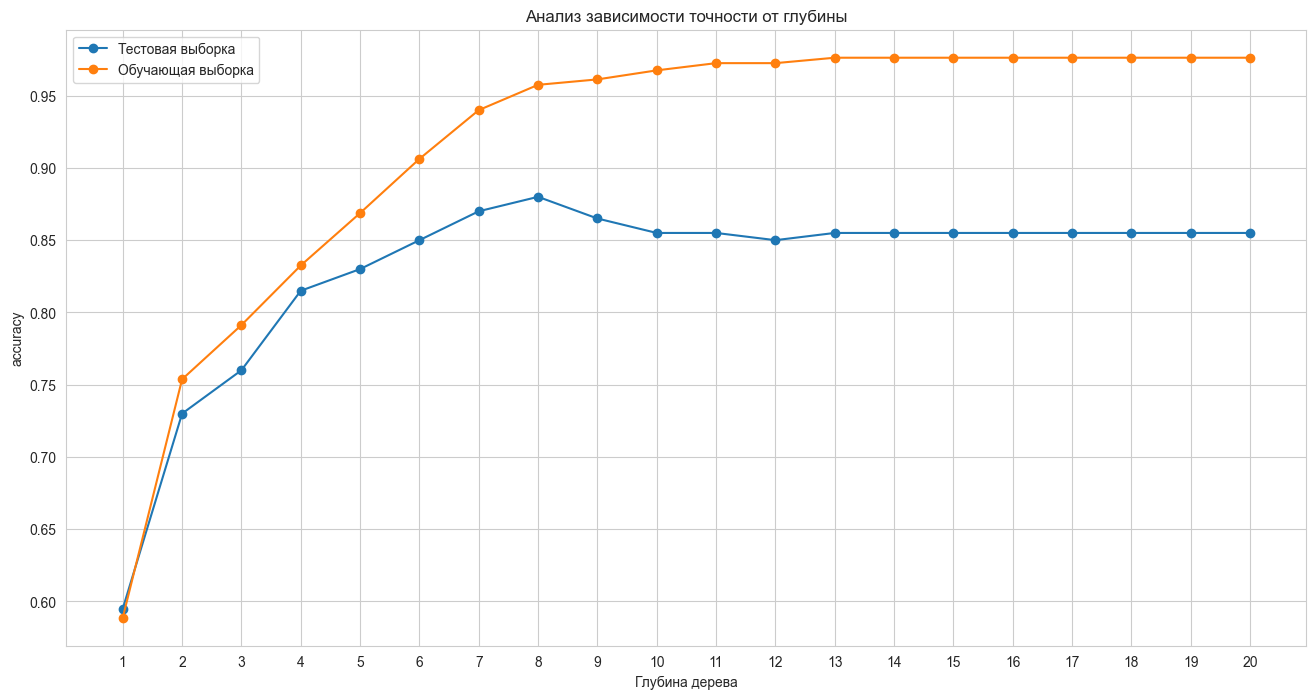

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


X, y = make_classification(n_samples=1000, n_features=5, n_informative=3,
                           n_classes=3, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
models = []
for d in range(1, 21):
    models.append(DecisionTreeClassifier(max_depth=d, min_samples_split=5, criterion='entropy', random_state=42))
    models[-1].fit(X_train, y_train)
pred_test = [accuracy_score(y_test, model.predict(X_test)) for model in models]
pred_train = [accuracy_score(y_train, model.predict(X_train)) for model in models]
plt.plot(np.arange(1, 21), pred_test, marker="o", label="Тестовая выборка")
plt.plot(np.arange(1, 21), pred_train, marker="o", label="Обучающая выборка")
plt.legend()
plt.xticks(np.arange(1, 21))
plt.grid(True)
plt.xlabel("Глубина дерева")
plt.ylabel("accuracy")
plt.title("Анализ зависимости точности от глубины")
plt.show()


1. Оптимальная глубина 8 (самый большой скор)
2. Модель слишком сложная при большой глубине и запоминает патерны из трейна слишком сильно в результате переобучаясь (трейн растёт а тест падает)

## Задание 5: Random Forest на реальных данных - предсказание цены квартир (5 баллов)

Используйте Random Forest для решения задачи **регрессии** - предсказания цены квартир на датасете с Kaggle.

**Датасет:** House Prices - Advanced Regression Techniques
- Ссылка: https://www.kaggle.com/c/house-prices-advanced-regression-techniques

**Задачи:**

1. **Загрузка и предобработка данных:**
   - Загрузите датасет (если нет доступа к Kaggle, используйте альтернативный датасет или создайте синтетический)
   - Проведите базовую предобработку: обработка пропусков (для дерева можно заполнять минимумом/максимумом), кодирование категориальных признаков

2. **Обучение моделей:**
   - Разделите данные на train/test
   - Обучите `DecisionTreeRegressor` с разными параметрами
   - Обучите `RandomForestRegressor` с разными параметрами:
     - Разное количество деревьев (10, 50, 100, 200)
     - Разные значения `max_features` ('sqrt', 'log2', 0.5)
     - Разные значения `max_depth` (5, 10, 15, None)

3. **Анализ результатов:**
   - Используйте метрики регрессии: MAE, MSE, RMSE, R²
   - Проанализируйте важность признаков
   - Используйте OOB score для Random Forest
   - Сравните результаты одного дерева и Random Forest

4. **Визуализация:**
   - Постройте график зависимости ошибки от количества деревьев
   - Визуализируйте важность признаков
   - Постройте график предсказанных vs реальных цен

5. **Выводы:**
   - Какая модель показала лучшие результаты?
   - Какие признаки наиболее важны для предсказания цены?
   - Как количество деревьев влияет на качество модели?


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import Pipeline
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, PredefinedSplit

df = pd.read_csv('train.csv')
X = df.drop(columns=['SalePrice', 'Id'])
y = df['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

preproc = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy='mean', ), make_column_selector(dtype_include='number')),
        ("cat", Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='constant', fill_value='null')),
            ('ohe', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
        ]), make_column_selector(dtype_include='object'))
    ]
).set_output(transform='pandas')

model1 = DecisionTreeRegressor(random_state=42)
model2 = RandomForestRegressor(random_state=42, oob_score=True)
X_train = preproc.fit_transform(X_train)
X_test = preproc.transform(X_test)

X_prc = pd.concat([X_train, X_test])
y_prc = pd.concat([y_train, y_test])

params1 = {
    'max_features': ('sqrt', 'log2', 0.5),
    'max_depth': (5, 10, 15, None)
}
params2 = {
    'n_estimators': (10, 50, 100, 200),
    'max_features': ('sqrt', 'log2', 0.5),
    'max_depth': (5, 10, 15, None)
}
metric = {
    'MAE': 'neg_mean_absolute_error',
    'MSE': 'neg_mean_squared_error',
    'R2': 'r2'
}

cv = PredefinedSplit([-1] * len(X_train) + [0] * len(X_test))
grid1 = GridSearchCV(model1, params1, scoring=metric, refit='MSE', n_jobs=-1, cv=cv)
grid2 = GridSearchCV(model2, params2, scoring=metric, refit='MSE', n_jobs=-1, cv=cv)
grid1.fit(X_prc, y_prc)
grid2.fit(X_prc, y_prc)


,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'max_depth': (5, ...), 'max_features': ('sqrt', ...), 'n_estimators': (10, ...)}"
,scoring,"{'MAE': 'neg_mean_absolute_error', 'MSE': 'neg_mean_squared_error', 'R2': 'r2'}"
,n_jobs,-1
,refit,'MSE'
,cv,"PredefinedSpl...hape=(1460,)))"
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,50


In [ ]:
bst1 = grid1.best_estimator_
bst2 = grid2.best_estimator_
pred1 = bst1.predict(X_test)
pred2 = bst2.predict(X_test)

def metrics(y_true, y_pred, name):
    print(f"Метрики для {name}:")
    print(f"MAE: {mean_absolute_error(y_true, y_pred):.2f}")
    print(f"MSE: {mean_squared_error(y_true, y_pred):.2f}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_true, y_pred)):.2f}")
    print(f"R2: {r2_score(y_true, y_pred):.4f}")

metrics(y_test, pred1, "DecisionTreeRegressor")
metrics(y_test, pred2, "RandomForestRegressor")
print(f"OOB скор у лучшего дерева: {bst2.oob_score_}")


Метрики для DecisionTreeRegressor:
MAE: 6816.33
MSE: 121297210.36
RMSE: 11013.50
R2: 0.9842
Метрики для RandomForestRegressor:
MAE: 6460.09
MSE: 118014665.42
RMSE: 10863.46
R2: 0.9846
OOB скор у лучшего дерева: 0.8583636309828875


вывод: рандомный лес покруче

In [ ]:
grid1_df = pd.DataFrame(grid1.cv_results_)
grid2_df = pd.DataFrame(grid2.cv_results_)
grid1_df["split0_test_MAE"] = -grid1_df["split0_test_MAE"]
grid1_df["split0_test_MSE"] = -grid1_df["split0_test_MSE"]
grid1_df["split0_test_RMSE"] = np.sqrt(grid1_df["split0_test_MSE"])
grid2_df["split0_test_MAE"] = -grid2_df["split0_test_MAE"]
grid2_df["split0_test_MSE"] = -grid2_df["split0_test_MSE"]
grid2_df["split0_test_RMSE"] = np.sqrt(grid2_df["split0_test_MSE"])


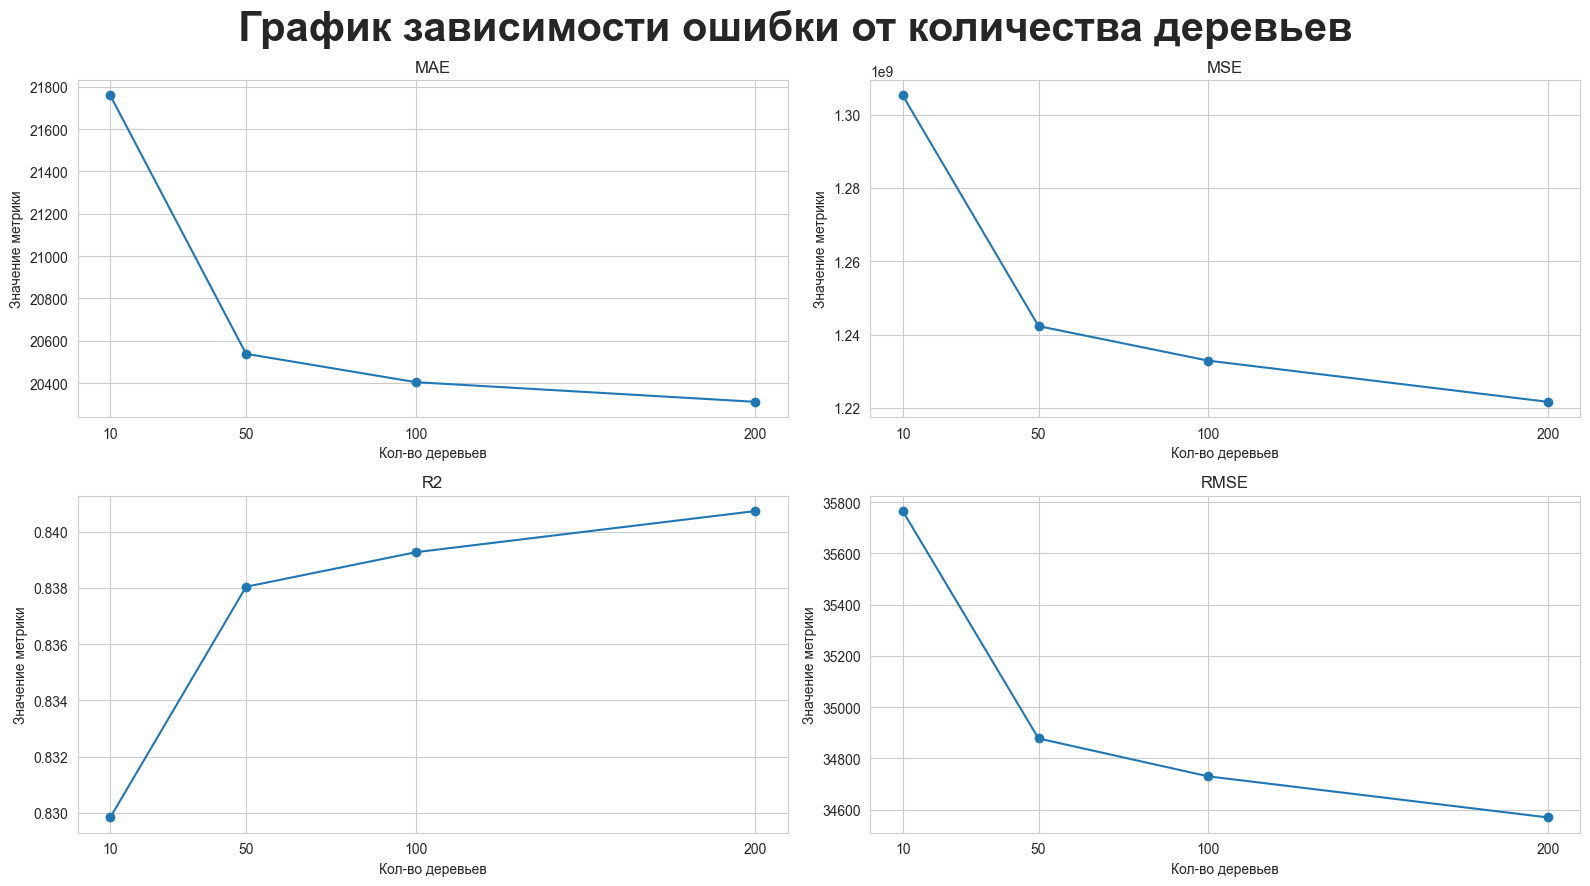

In [ ]:
result = grid2_df.groupby("param_n_estimators")[["split0_test_MAE", "split0_test_MSE", "split0_test_R2", "split0_test_RMSE"]].mean().rename(columns={"split0_test_MAE": 'MAE', "split0_test_MSE": 'MSE', "split0_test_R2": "R2", 'split0_test_RMSE': 'RMSE'})
fig, axs = plt.subplots(2, 2, figsize=(16, 9))
axfs = axs.flatten()
result_dict = result.to_dict()
plt.suptitle("График зависимости ошибки от количества деревьев", fontsize=30, fontweight='bold')
for i, key in enumerate(result_dict):
    axfs[i].plot(result_dict[key].keys(), result_dict[key].values(), marker="o")
    axfs[i].set_xlabel("Кол-во деревьев")
    axfs[i].set_ylabel("Значение метрики")
    axfs[i].set_title(key)
    axfs[i].set_xticks(list(result_dict["RMSE"].keys()))
    plt.grid(True)

plt.tight_layout()
plt.show()

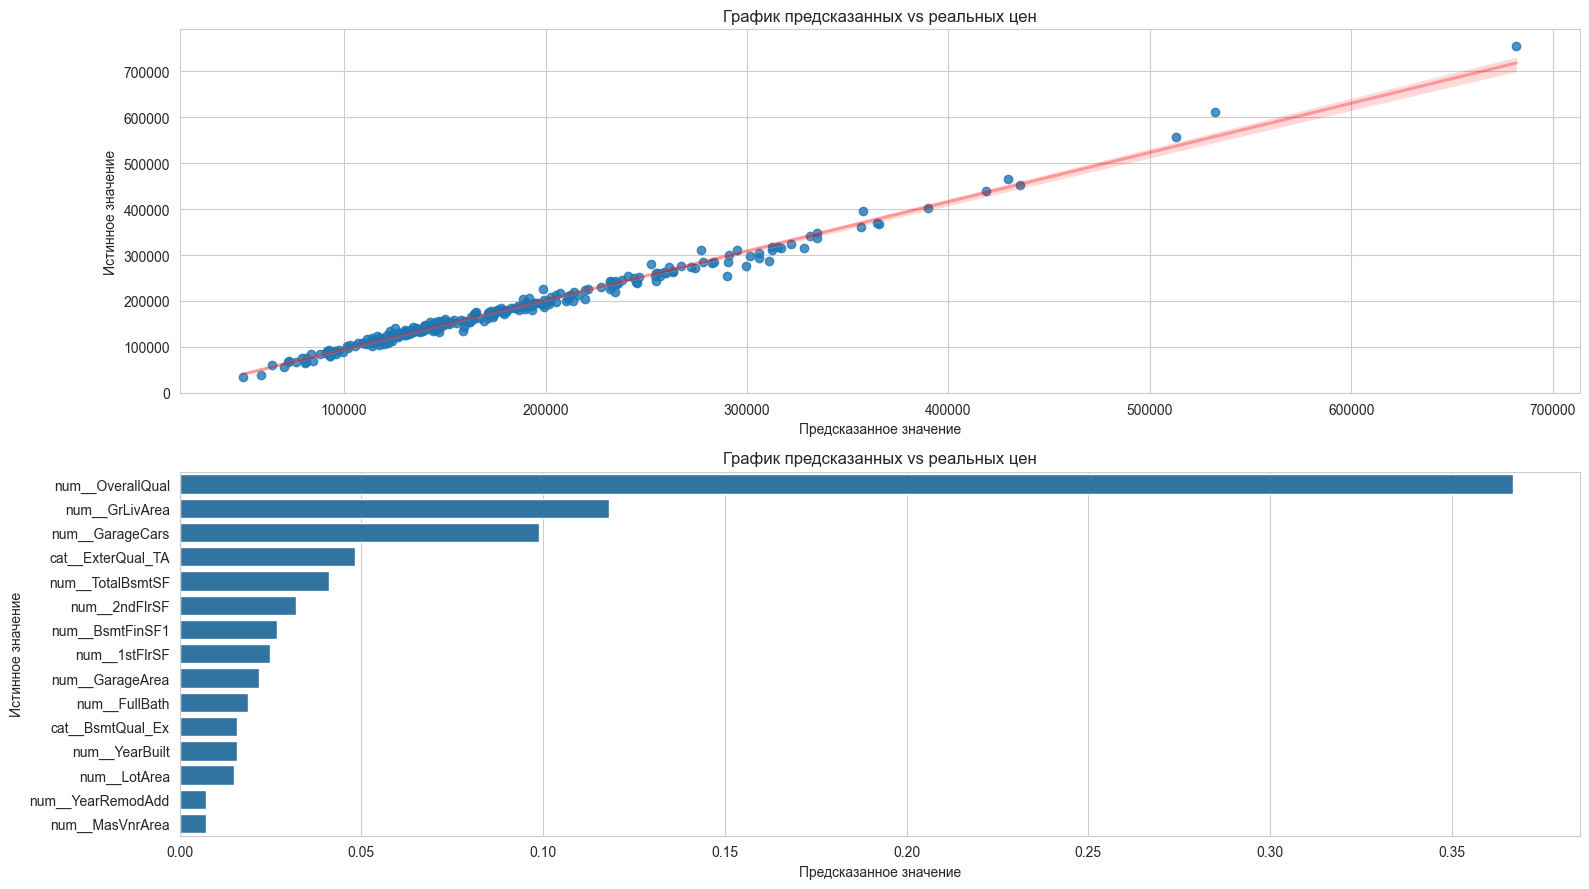

In [ ]:
fig, axs = plt.subplots(2, 1, figsize=(16, 9))
axfs = axs.flatten()
pred = bst2.predict(X_test)
sns.regplot(x=pred, y=y_test.values, ax=axfs[0], line_kws={'color': "r", 'alpha': 0.3})
axfs[0].set_xlabel("Предсказанное значение")
axfs[0].set_ylabel("Истинное значение")
axfs[0].set_title("График предсказанных vs реальных цен")
feature_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': bst2.feature_importances_
}).sort_values(by='importance', ascending=False)
sns.barplot(data=feature_df.head(15), x='importance', y='feature', ax=axfs[1])
axfs[1].set_xlabel("Предсказанное значение")
axfs[1].set_ylabel("Истинное значение")
axfs[1].set_title("График предсказанных vs реальных цен")
plt.tight_layout()
plt.show()

1) Лучшие результаты показала модель RandomForestRegressor с параметрами n_estimators = 50, max_depth = 15, max_features = 0.5 по метрике MSE
2) Наиболее важные признаки: OverallQual (качество жизни), GrLivArea(жилая площадь), эти два фактора напрямую влияют на цену, т.к. первый фактор показывает качество материалов и отделки, а 2 является одной из главной характеристик жилищ
3) При увеличении числа деревьев модель всё ближе стремится к наилучшему (из возможного) значению, улучшая результат, при этом модель не переобучается, это видно из OOB коэфицента



## Задание 6: Визуализация дерева решений (1 балл)

Обучите дерево решений на датасете ирисов (или другом) и:

1. Визуализируйте структуру дерева с помощью `plot_tree`
2. Объясните путь предсказания для одного примера от корня до листа


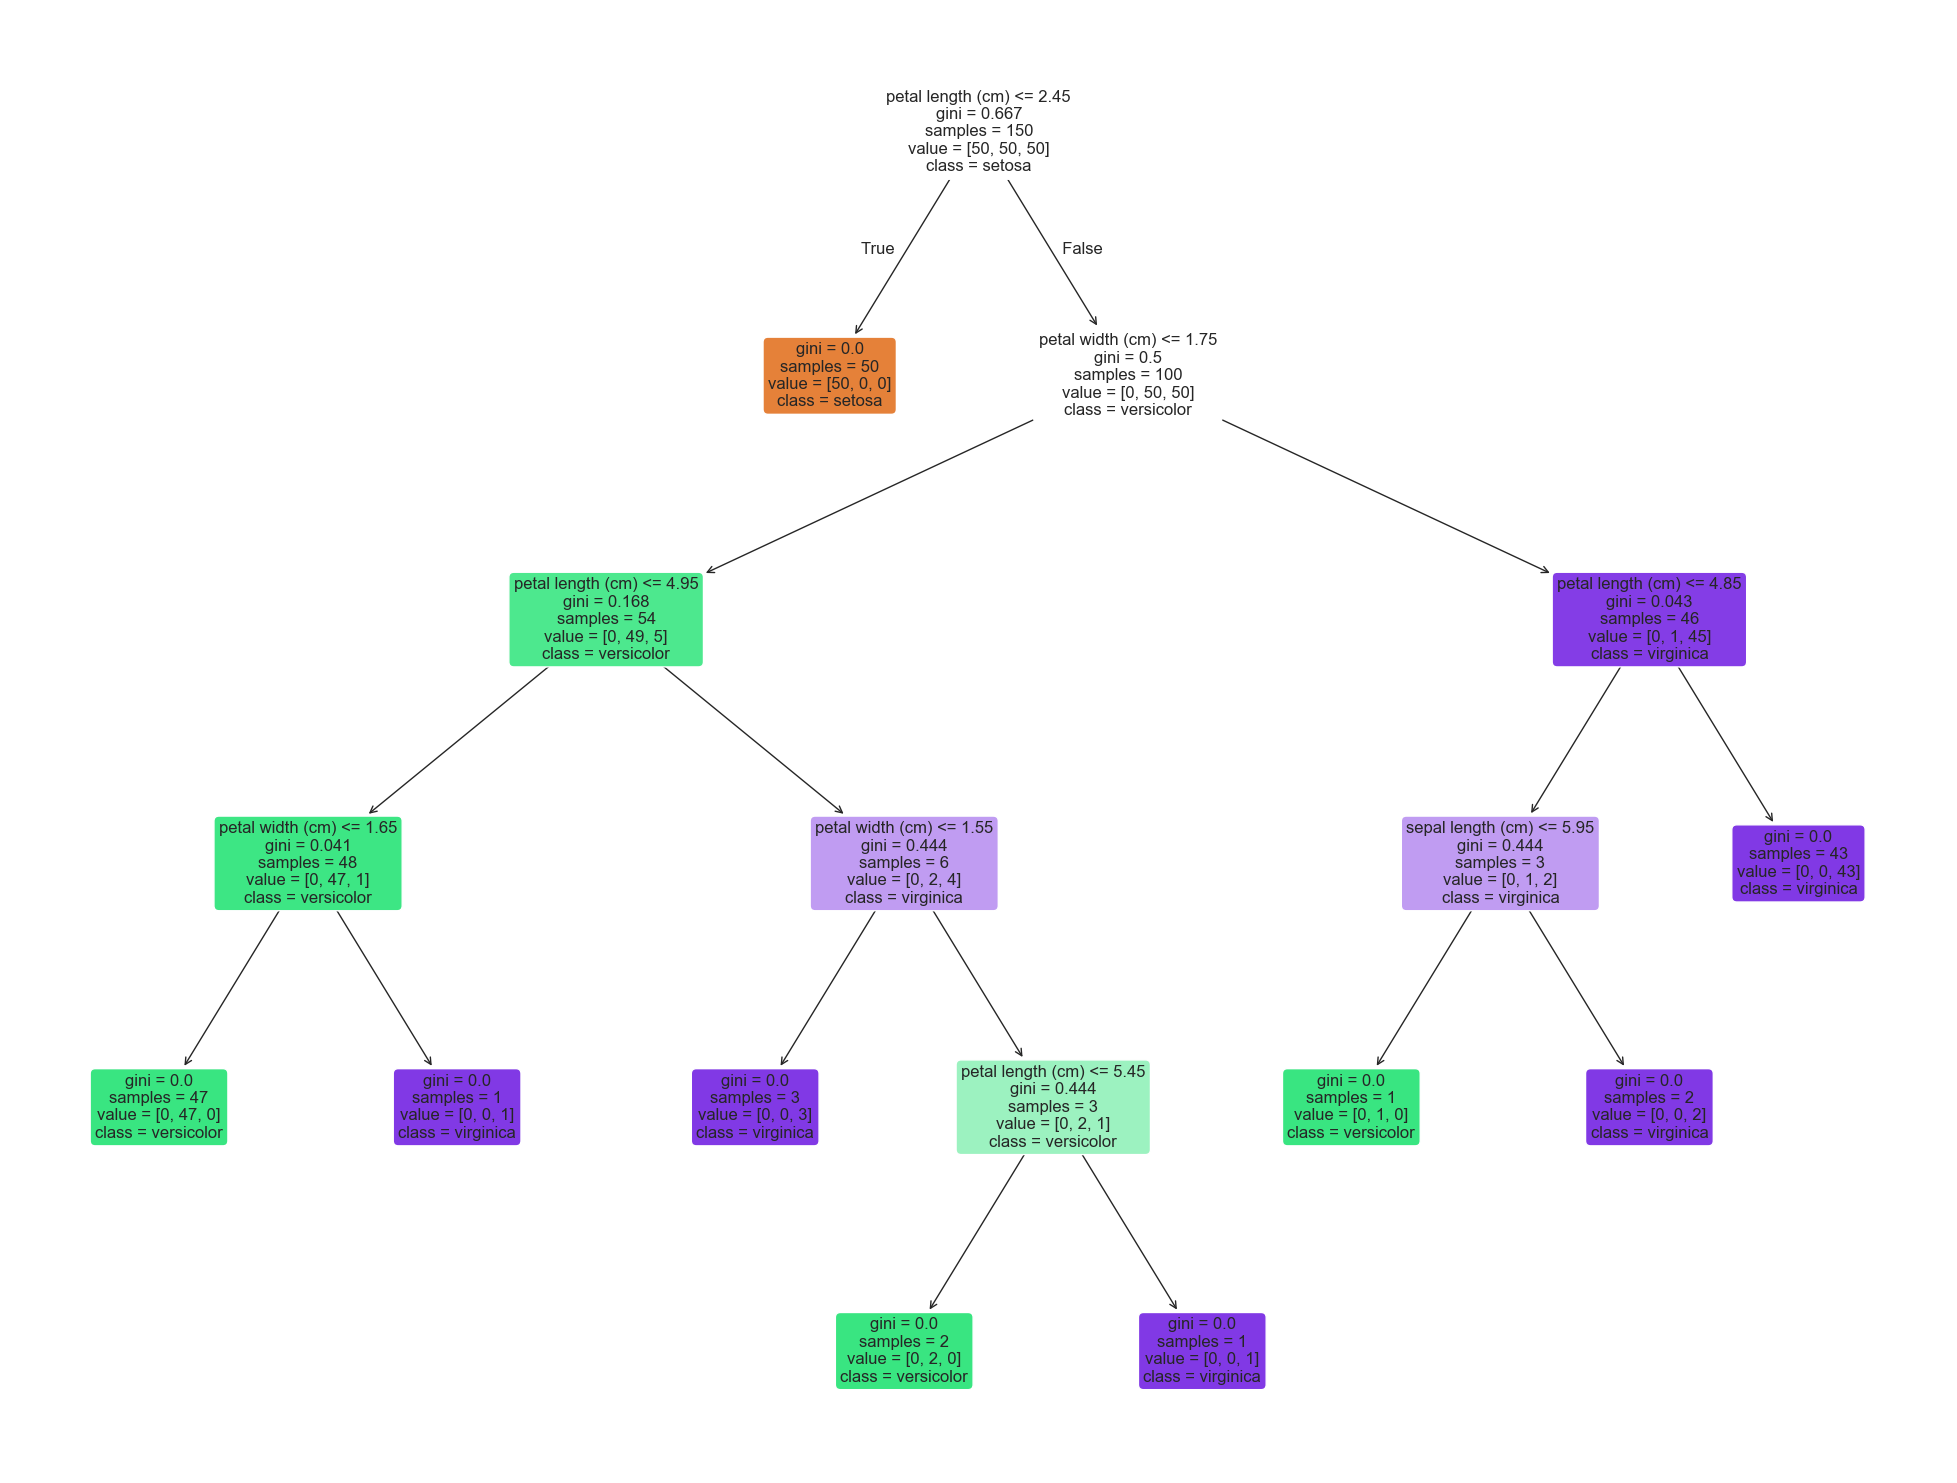

In [ ]:
from sklearn.tree import plot_tree
from sklearn.datasets import load_iris

dataset = load_iris()
X, y = dataset.data, dataset.target
model = DecisionTreeClassifier(max_depth=5, random_state=42)
model.fit(X, y)
plt.figure(figsize=(25, 19))
plot_tree(model, feature_names=dataset.feature_names, class_names=dataset.target_names, filled=True, rounded=True, fontsize=12)
plt.show()


In [ ]:
print(dataset.feature_names)
print(X[100])
print(dataset.target_names)
print(y[100])

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
[6.3 3.3 6.  2.5]
['setosa' 'versicolor' 'virginica']
2


Для цветка с параметрами sepal length (cm): 6.3, sepal width (cm): 3.3, petal length (cm): 6., petal width (cm): 2.5
Вначале мы идём на право (тк petal length 6 > 2.45), потом идём опять направо (тк petal width 2.5 > 1.75), потом идём опять направо (тк petal length 6 > 4.85) и это класс virginica, модель верно предсказала.

## Задание 7: Оптимизация гиперпараметров (2 балла)

Используйте `GridSearchCV` или `optuna` для оптимизации гиперпараметров Random Forest:

1. Выберите датасет
2. Определите сетку параметров для поиска:
   - `n_estimators`: [50, 100, 200]
   - `max_depth`: [5, 10, 15, None]
   - `min_samples_split`: [2, 5, 10]
   - `max_features`: ['sqrt', 'log2', 0.5]
3. Выполните поиск оптимальных параметров
4. Обучите финальную модель с лучшими параметрами
5. Сравните с моделью с параметрами по умолчанию


In [ ]:
# Ваш код здесь
from sklearn.model_selection import GridSearchCV
import optuna

model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)
# модель я обучал уже выше с грид сёрчем так что воспользуюсь ей
print("RMSE тюненой модели:", np.sqrt(mean_squared_error(y_test, pred2)))
print("RMSE дефолтной модели:", np.sqrt(mean_squared_error(y_test, model.predict(X_test))))


e:\distributiv\python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


RMSE тюненой модели: 10863.455501120343
RMSE дефолтной модели: 42132.25111702858


Вывод: колосальная разница

## Бонусное задание: Реализация Random Forest (5 баллов)

Реализуйте упрощённую версию Random Forest Classifier:

1. Класс `SimpleRandomForest` с методами `fit` и `predict`
2. Используйте бутстрап-выборки для создания разных обучающих наборов
3. Используйте feature bagging (случайный выбор признаков при разбиении)
4. Объедините предсказания деревьев через голосование
5. Протестируйте на датасете и сравните с `sklearn.ensemble.RandomForestClassifier`

Используйте вашу реализацию `SimpleDecisionTree` из задания 3


In [ ]:
class SimpleRandomForest:
    def __init__(self, n_estimators=100, max_depth=10, max_features='sqrt'):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.max_features = max_features
        self.trees = []

    def fit(self, X, y):
        n = X.shape[0]
        if self.max_features == 'sqrt':
            m = int(np.sqrt(n))
        elif self.max_features is None:
            m = n
        else:
            m = self.max_features
        for i in range(self.n_estimators):
            tree = SimpleDecisionTree(self.max_depth)
            mask = np.random.choice(n, size=n, replace=True)
            tree.fit(X[mask], y[mask], max_feature=m)
            self.trees.append(tree)

    def predict(self, X):
        preds = np.array([tree.predict(X) for tree in self.trees])
        ans = []
        for i in range(X.shape[0]):
            x = preds[:, i]
            arr, cnt = np.unique(x, return_counts=True)
            ans.append(arr[np.argmax(cnt)])
        return ans

X, y = make_classification(n_samples=1000, n_features=5, n_informative=3,
                           n_classes=3, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

moi_krutoe_derevo = SimpleRandomForest(n_estimators=10, max_depth=3)
plohoe_derevo_skkit = RandomForestClassifier(n_estimators=10, max_depth=3, random_state=42)
moi_krutoe_derevo.fit(X_train, y_train)
plohoe_derevo_skkit.fit(X_train, y_train)
pred_my = moi_krutoe_derevo.predict(X_test)
pred_sk = plohoe_derevo_skkit.predict(X_test)

s1 = accuracy_score(y_test, pred_my)
s2 = accuracy_score(y_test, pred_sk)
print("Accuracy (Моё):", s1)
print("Accuracy (Ск лёрна:)", s2)


Accuracy (Моё): 0.7533333333333333
Accuracy (Ск лёрна:) 0.7966666666666666


похуже ск лёрна, но норм

---

## Итоговая оценка

**Максимальный балл: 20 + 5 (бонус) = 25 баллов**

- Задание 1: 2 балла
- Задание 2: 3 балла
- Задание 3: 5 баллов (основное программирование)
- Задание 4: 2 балла
- Задание 5: 5 баллов
- Задание 6: 1 балл
- Задание 7: 2 балла
- Бонусное задание: 5 баллов

**Удачи! 🍀**
